# Anomaly Detection Using Linear Regression
## National Parks Visitation Data

This notebook implements anomaly detection using linear regression based on the methodology from:
https://medium.com/@amit25173/linear-regression-anomaly-detection-fc29405140ca

### Methodology:
1. Train a linear regression model on the data
2. Calculate residuals (actual - predicted values)
3. Identify anomalies as data points where residuals exceed N standard deviations from the mean
4. Visualize and analyze the detected anomalies


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1. Load and Prepare Data

We'll work with both yearly and monthly data to detect anomalies at different time scales.


In [74]:
# Load yearly data
df_yearly = pd.read_csv('Datasets/historic_park_data.csv', thousands=',')
df_yearly.fillna(0, inplace=True)
df_yearly["Date"] = pd.to_datetime(df_yearly["Year"].astype(str), format="%Y")

print("Yearly Data Shape:", df_yearly.shape)
print("\nColumns:", df_yearly.columns.tolist())
print("\nNumber of Parks:", df_yearly['ParkName'].nunique())
df_yearly.head()


Yearly Data Shape: (5282, 8)

Columns: ['ParkName', 'UnitCode', 'ParkType', 'Region', 'State', 'Year', 'Total', 'Date']

Number of Parks: 63


,ParkName,UnitCode,ParkType,Region,State,Year,Total,Date
0,Acadia NP,ACAD,National Park,Northeast,ME,1919,64000,1919-01-01
1,Acadia NP,ACAD,National Park,Northeast,ME,1920,66500,1920-01-01
2,Acadia NP,ACAD,National Park,Northeast,ME,1921,69836,1921-01-01
3,Acadia NP,ACAD,National Park,Northeast,ME,1922,73779,1922-01-01
4,Acadia NP,ACAD,National Park,Northeast,ME,1923,64200,1923-01-01


In [75]:
# Load monthly data
df_monthly = pd.read_csv('Datasets/national_parks_cleaned.csv')
df_monthly.fillna(0, inplace=True)
df_monthly["Date"] = pd.to_datetime(df_monthly["Year"].astype(str) + "-" + df_monthly["Month"], format="%Y-%B")

print("Monthly Data Shape:", df_monthly.shape)
print("\nColumns:", df_monthly.columns.tolist())
print("\nNumber of Parks:", df_monthly['ParkName'].nunique())
df_monthly.head()


Monthly Data Shape: (34643, 19)

Columns: ['ParkName', 'UnitCode', 'ParkType', 'Region', 'State', 'Year', 'Month', 'RecreationVisits', 'NonRecreationVisits', 'RecreationHours', 'NonRecreationHours', 'ConcessionerLodging', 'ConcessionerCamping', 'TentCampers', 'RVCampers', 'Backcountry', 'NonRecreationOvernightStays', 'MiscellaneousOvernightStays', 'Date']

Number of Parks: 64


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,RecreationHours,NonRecreationHours,ConcessionerLodging,ConcessionerCamping,TentCampers,RVCampers,Backcountry,NonRecreationOvernightStays,MiscellaneousOvernightStays,Date
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,January,6011.0,15252.0,37446.0,15252.0,0.0,0.0,102.0,13.0,0.0,0.0,0.0,1979-01-01
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,February,5243.0,13776.0,17661.0,13776.0,0.0,0.0,53.0,8.0,0.0,0.0,0.0,1979-02-01
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,March,11165.0,15252.0,36051.0,15252.0,0.0,0.0,176.0,37.0,0.0,0.0,0.0,1979-03-01
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,April,219351.0,37657.0,1334058.0,37657.0,0.0,0.0,1037.0,459.0,0.0,0.0,0.0,1979-04-01
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,May,339416.0,50616.0,2088588.0,50616.0,0.0,0.0,3193.0,1148.0,0.0,0.0,0.0,1979-05-01


## 2. Anomaly Detection Functions

Define reusable functions for anomaly detection using linear regression.


In [76]:
def detect_anomalies_lr(X, y, threshold=3, test_size=0.2):
    """
    Detect anomalies using linear regression residuals.
    
    Parameters:
    -----------
    X : array-like
        Feature variables
    y : array-like
        Target variable
    threshold : float
        Number of standard deviations from mean to consider as anomaly (default=3)
    test_size : float
        Proportion of data to use for testing (default=0.2)
    
    Returns:
    --------
    dict : Dictionary containing model, predictions, residuals, and anomaly information
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate residuals
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred
    
    # Calculate statistics from training residuals
    mean_residual = np.mean(residuals_train)
    std_residual = np.std(residuals_train)
    
    # Define anomaly threshold
    anomaly_threshold = threshold * std_residual
    
    # Identify anomalies in test set
    anomaly_mask_test = np.abs(residuals_test - mean_residual) > anomaly_threshold
    
    # Calculate metrics
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    return {
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'residuals_train': residuals_train,
        'residuals_test': residuals_test,
        'mean_residual': mean_residual,
        'std_residual': std_residual,
        'anomaly_threshold': anomaly_threshold,
        'anomaly_mask': anomaly_mask_test,
        'n_anomalies': np.sum(anomaly_mask_test),
        'anomaly_percentage': 100 * np.sum(anomaly_mask_test) / len(y_test),
        'r2_train': r2_train,
        'r2_test': r2_test,
        'mse': mse_test,
        'mae': mae_test
    }


In [77]:
def plot_anomalies(results, dates, park_name='', save_path=None, display=True):
    """
    Visualize anomaly detection results.
    
    Parameters:
    -----------
    results : dict
        Results dictionary from detect_anomalies_lr function
    dates : array-like
        Date values for x-axis
    park_name : str
        Name of the park for title
    save_path : str
        Path to save the figure (optional)
    display : bool
        Whether to display the plot (default=True)
    """
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Plot 1: Actual vs Predicted with Anomalies
    ax1 = axes[0]
    all_indices = np.concatenate([results['X_train'].index, results['X_test'].index])
    all_dates = dates.loc[all_indices]
    all_actuals = np.concatenate([results['y_train'], results['y_test']])
    all_predictions = np.concatenate([results['y_train_pred'], results['y_test_pred']])
    
    ax1.plot(all_dates, all_actuals, 'o-', label='Actual', alpha=0.7, markersize=4)
    ax1.plot(all_dates, all_predictions, 'r-', label='Predicted', linewidth=2)
    
    # Highlight anomalies
    if results['n_anomalies'] > 0:
        anomaly_indices = results['X_test'].index[results['anomaly_mask']]
        anomaly_dates = dates.loc[anomaly_indices]
        anomaly_values = results['y_test'][results['anomaly_mask']]
        ax1.scatter(anomaly_dates, anomaly_values, color='red', s=100, 
                   marker='X', label='Anomalies', zorder=5, edgecolors='black', linewidth=1.5)
    
    ax1.axvline(x=dates.loc[results['X_test'].index[0]], color='gray', 
               linestyle='--', label='Train/Test Split', alpha=0.7)
    ax1.set_title(f'{park_name} - Actual vs Predicted\nR² (Train): {results["r2_train"]:.3f}, R² (Test): {results["r2_test"]:.3f}', 
                 fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Number of Visitors')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Residuals over time
    ax2 = axes[1]
    train_dates = dates.loc[results['X_train'].index]
    test_dates = dates.loc[results['X_test'].index]
    
    ax2.scatter(train_dates, results['residuals_train'], alpha=0.5, label='Training Residuals')
    ax2.scatter(test_dates, results['residuals_test'], alpha=0.7, label='Test Residuals', color='orange')
    
    # Draw threshold lines
    ax2.axhline(y=results['mean_residual'] + results['anomaly_threshold'], 
               color='red', linestyle='--', label=f'Anomaly Threshold (±{results["anomaly_threshold"]:.0f})', linewidth=2)
    ax2.axhline(y=results['mean_residual'] - results['anomaly_threshold'], 
               color='red', linestyle='--', linewidth=2)
    ax2.axhline(y=results['mean_residual'], color='green', linestyle='-', 
               label=f'Mean Residual ({results["mean_residual"]:.0f})', linewidth=1.5)
    
    # Highlight anomalies
    if results['n_anomalies'] > 0:
        anomaly_residuals = results['residuals_test'][results['anomaly_mask']]
        ax2.scatter(anomaly_dates, anomaly_residuals, color='red', s=100, 
                   marker='X', label='Anomalies', zorder=5, edgecolors='black', linewidth=1.5)
    
    ax2.set_title('Residuals Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Residuals')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Residual Distribution
    ax3 = axes[2]
    ax3.hist(results['residuals_train'], bins=30, alpha=0.7, label='Training Residuals', density=True)
    ax3.hist(results['residuals_test'], bins=30, alpha=0.7, label='Test Residuals', density=True)
    
    # Add vertical lines for thresholds
    ax3.axvline(x=results['mean_residual'] + results['anomaly_threshold'], 
               color='red', linestyle='--', linewidth=2)
    ax3.axvline(x=results['mean_residual'] - results['anomaly_threshold'], 
               color='red', linestyle='--', linewidth=2, label='Anomaly Threshold')
    ax3.axvline(x=results['mean_residual'], color='green', linestyle='-', 
               linewidth=1.5, label='Mean Residual')
    
    ax3.set_title('Residual Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Residuals')
    ax3.set_ylabel('Density')
    ax3.legend(loc='best')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    if display:
        plt.show()
    else:
        plt.close(fig)


In [78]:
def sensitivity_analysis(X, y, thresholds=[1.5, 2, 2.5, 3, 3.5, 4]):
    """
    Perform sensitivity analysis for different anomaly thresholds.
    
    Parameters:
    -----------
    X : array-like
        Feature variables
    y : array-like
        Target variable
    thresholds : list
        List of threshold values to test
    
    Returns:
    --------
    DataFrame : Summary of anomalies detected at each threshold
    """
    results = []
    
    for threshold in thresholds:
        anomaly_results = detect_anomalies_lr(X, y, threshold=threshold)
        results.append({
            'Threshold (σ)': threshold,
            'Anomalies Detected': anomaly_results['n_anomalies'],
            'Percentage': f"{anomaly_results['anomaly_percentage']:.2f}%",
            'R² Test': f"{anomaly_results['r2_test']:.3f}"
        })
    
    return pd.DataFrame(results)


## 3. Yearly Data Anomaly Detection

Detect anomalies in yearly visitation data for all parks.

**Strategy:**
- 📊 **Statistics**: Top 3 parks statistics shown below
- ❌ **No Individual Plots Displayed**: All plots saved to disk only
- 💾 **Save**: All parks (to `linear_regression_anomalies/yearly/`)
- 📈 **Combine**: All parks with z-score standardization (displayed in section 5)


In [79]:
# Get list of all parks
park_list_yearly = df_yearly['ParkName'].unique()
print(f"Analyzing {len(park_list_yearly)} parks...\n")


Analyzing 63 parks...



In [80]:
# Identify top 3 parks by total visitation
top_3_parks = df_yearly.groupby('ParkName')['Total'].sum().sort_values(ascending=False).head(3).index.tolist()
print(f"Top 3 parks by visitation: {top_3_parks}")
print("\n" + "="*60)
print("📊 ANALYSIS STRATEGY:")
print("="*60)
print("✅ Showing statistics for top 3 parks")
print("❌ NO individual plots displayed (to reduce clutter)")
print("💾 All park plots saved to disk in section 6")
print("📈 Combined analysis displayed in section 5")
print("="*60 + "\n")


Top 3 parks by visitation: ['Great Smoky Mountains NP', 'Yosemite NP', 'Grand Canyon NP']

📊 ANALYSIS STRATEGY:
✅ Showing statistics for top 3 parks
❌ NO individual plots displayed (to reduce clutter)
💾 All park plots saved to disk in section 6
📈 Combined analysis displayed in section 5



### Analyze Top 3 Parks - Yearly Data (Stats Only - No Plots Displayed)


In [81]:
# Analyze top 3 parks - print stats only, save plots without displaying
for park_name in top_3_parks:
    park_data = df_yearly[df_yearly["ParkName"] == park_name].copy()
    park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)

    X = park_data[['MonthIndex']]
    y = park_data['Total']

    # Detect anomalies with 3 sigma threshold
    results = detect_anomalies_lr(X, y, threshold=3)

    print(f"\n{'='*60}")
    print(f"Anomaly Detection Results for {park_name}")
    print(f"{'='*60}")
    print(f"R² Score (Train): {results['r2_train']:.3f}")
    print(f"R² Score (Test): {results['r2_test']:.3f}")
    print(f"Mean Squared Error: {results['mse']:,.0f}")
    print(f"Mean Absolute Error: {results['mae']:,.0f}")
    print(f"\nResiduals Mean: {results['mean_residual']:,.2f}")
    print(f"Residuals Std: {results['std_residual']:,.2f}")
    print(f"Anomaly Threshold: 3σ = {results['anomaly_threshold']:,.2f}")
    print(f"\nNumber of Anomalies Detected: {results['n_anomalies']}")
    print(f"Percentage of Test Data: {results['anomaly_percentage']:.2f}%")

    if results['n_anomalies'] > 0:
        print(f"\nAnomaly Details:")
        anomaly_indices = results['X_test'].index[results['anomaly_mask']]
        anomaly_data = park_data.loc[anomaly_indices, ['Date', 'Year', 'Total']]
        anomaly_data['Predicted'] = results['y_test_pred'][results['anomaly_mask']]
        anomaly_data['Residual'] = results['residuals_test'][results['anomaly_mask']].values
        print(anomaly_data.to_string())

    # Save plot without displaying (plot saved in later section with all parks)
    print(f"⚠️  Plot will be saved in section 6 along with all other parks")



Anomaly Detection Results for Great Smoky Mountains NP
R² Score (Train): 0.928
R² Score (Test): -3.460
Mean Squared Error: 7,539,011,453,742
Mean Absolute Error: 2,557,022

Residuals Mean: -0.00
Residuals Std: 2,055,845.81
Anomaly Threshold: 3σ = 6,167,537.42

Number of Anomalies Detected: 0
Percentage of Test Data: 0.00%
⚠️  Plot will be saved in section 6 along with all other parks

Anomaly Detection Results for Yosemite NP
R² Score (Train): 0.817
R² Score (Test): -0.729
Mean Squared Error: 1,000,394,837,180
Mean Absolute Error: 614,364

Residuals Mean: -0.00
Residuals Std: 880,051.70
Anomaly Threshold: 3σ = 2,640,155.10

Number of Anomalies Detected: 1
Percentage of Test Data: 4.17%

Anomaly Details:
           Date  Year    Total     Predicted      Residual
5171 2020-01-01  2020  2869443  6.412536e+06 -3.543093e+06
⚠️  Plot will be saved in section 6 along with all other parks

Anomaly Detection Results for Grand Canyon NP
R² Score (Train): 0.871
R² Score (Test): -0.193
Mean Squar

### Analyze All Parks (Yearly Data)


In [82]:
# Store results for all parks
all_parks_results = []

for park_name in park_list_yearly:
    try:
        park_data = df_yearly[df_yearly["ParkName"] == park_name].copy()
        
        # Skip if too few data points
        if len(park_data) < 10:
            continue
        
        park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)
        
        X = park_data[['MonthIndex']]
        y = park_data['Total']
        
        # Detect anomalies
        results = detect_anomalies_lr(X, y, threshold=3)
        
        all_parks_results.append({
            'Park': park_name,
            'Data Points': len(park_data),
            'Test Points': len(results['y_test']),
            'R² Train': results['r2_train'],
            'R² Test': results['r2_test'],
            'MAE': results['mae'],
            'Anomalies': results['n_anomalies'],
            'Anomaly %': results['anomaly_percentage']
        })
        
    except Exception as e:
        print(f"Error processing {park_name}: {str(e)}")
        continue

# Create summary DataFrame
summary_df = pd.DataFrame(all_parks_results)
summary_df = summary_df.sort_values('Anomalies', ascending=False)

print(f"\nSummary of Anomaly Detection Across All Parks (Yearly Data)")
print("="*80)
print(summary_df.to_string(index=False))



Summary of Anomaly Detection Across All Parks (Yearly Data)
                           Park  Data Points  Test Points  R² Train     R² Test          MAE  Anomalies  Anomaly %
                Kings Canyon NP          121           25  0.843176  -53.008823 6.667639e+05         21  84.000000
                Mammoth Cave NP           89           18  0.837398 -372.023684 2.086433e+06         18 100.000000
                     Olympic NP           90           18  0.952256  -15.475804 1.560442e+06         15  83.333333
            Carlsbad Caverns NP          101           21  0.631538  -69.713564 5.219994e+05         14  66.666667
                Gateway Arch NP           84           17  0.731907  -16.798017 2.544273e+06         11  64.705882
                 Joshua Tree NP           84           17  0.948452   -0.530720 7.527786e+05         10  58.823529
                      Arches NP           96           20  0.830107   -1.393371 4.006019e+05         10  50.000000
                   

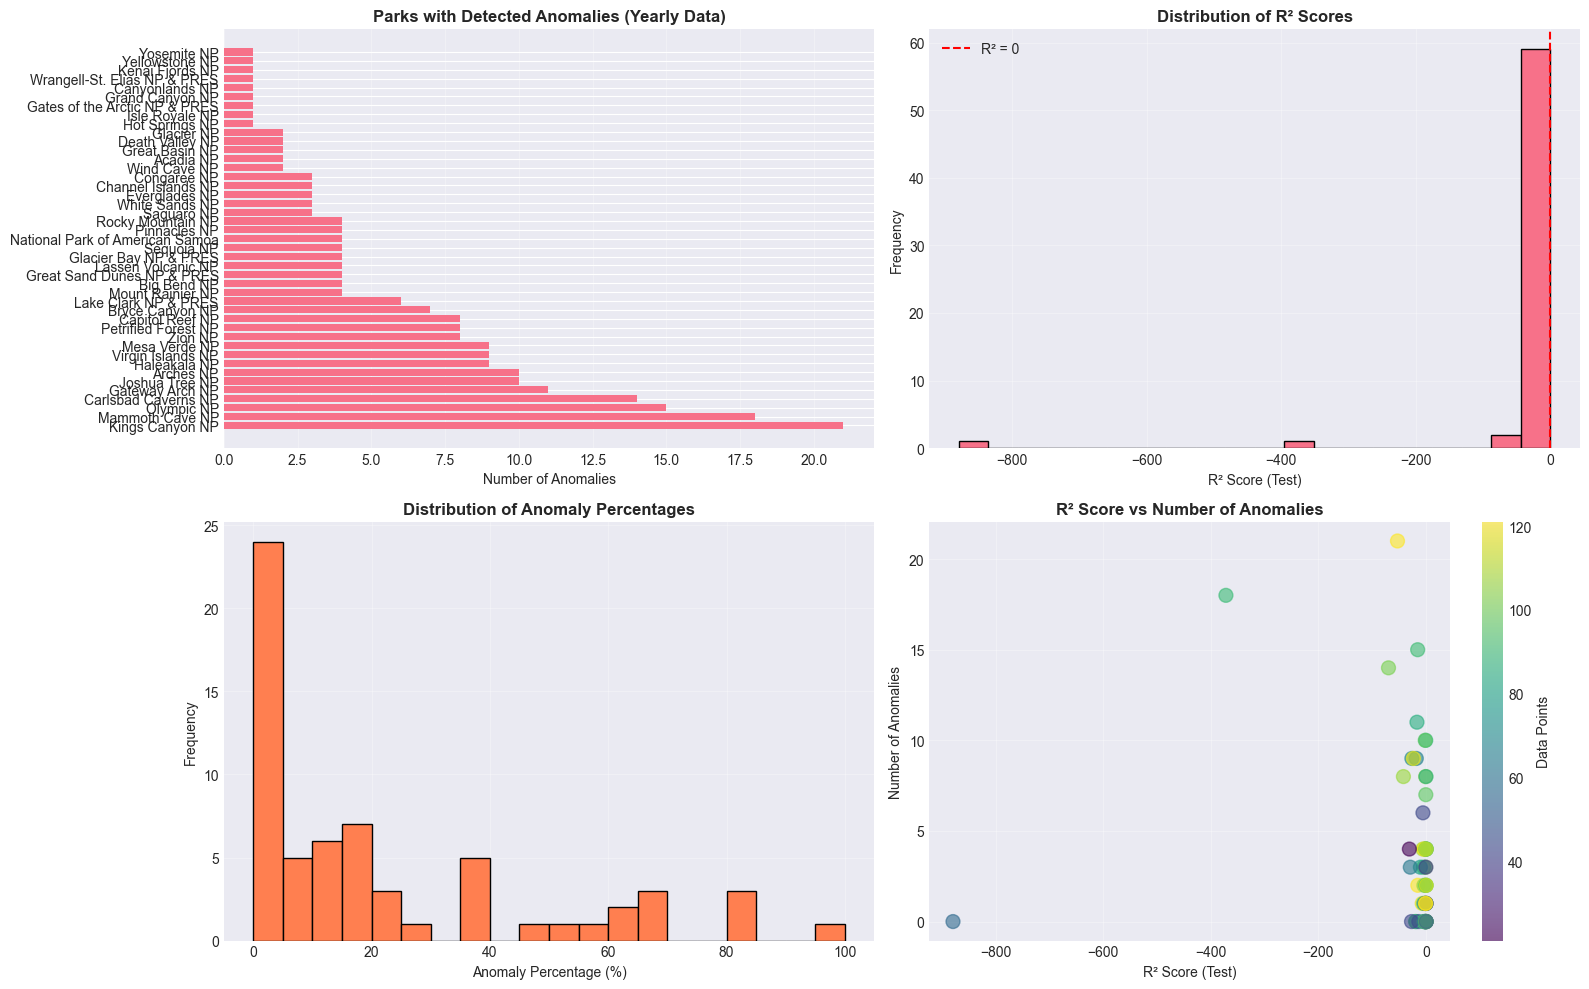

In [83]:
# Visualize summary statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Number of anomalies per park
ax1 = axes[0, 0]
parks_with_anomalies = summary_df[summary_df['Anomalies'] > 0]
if len(parks_with_anomalies) > 0:
    ax1.barh(parks_with_anomalies['Park'], parks_with_anomalies['Anomalies'])
    ax1.set_xlabel('Number of Anomalies')
    ax1.set_title('Parks with Detected Anomalies (Yearly Data)', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
else:
    ax1.text(0.5, 0.5, 'No anomalies detected', ha='center', va='center', fontsize=12)
    ax1.set_title('Parks with Detected Anomalies (Yearly Data)', fontweight='bold')

# Plot 2: R² distribution
ax2 = axes[0, 1]
ax2.hist(summary_df['R² Test'], bins=20, edgecolor='black')
ax2.set_xlabel('R² Score (Test)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of R² Scores', fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', label='R² = 0')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Anomaly percentage distribution
ax3 = axes[1, 0]
ax3.hist(summary_df['Anomaly %'], bins=20, edgecolor='black', color='coral')
ax3.set_xlabel('Anomaly Percentage (%)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Anomaly Percentages', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: R² vs Anomaly count
ax4 = axes[1, 1]
scatter = ax4.scatter(summary_df['R² Test'], summary_df['Anomalies'], 
                     c=summary_df['Data Points'], cmap='viridis', s=100, alpha=0.6)
ax4.set_xlabel('R² Score (Test)')
ax4.set_ylabel('Number of Anomalies')
ax4.set_title('R² Score vs Number of Anomalies', fontweight='bold')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='Data Points')

plt.tight_layout()
plt.show()


## 4. Monthly Data Anomaly Detection

Detect anomalies in monthly visitation data (more granular analysis).

**Strategy:**
- 📊 **Statistics**: Top 3 parks statistics shown below
- ❌ **No Individual Plots Displayed**: All plots saved to disk only
- 💾 **Save**: All parks (to `linear_regression_anomalies/monthly/`)
- 📈 **Combine**: All parks with z-score standardization (displayed in section 5)


In [84]:
# Identify top 3 parks by recreation visits (monthly data)
top_3_parks_monthly = df_monthly.groupby('ParkName')['RecreationVisits'].sum().sort_values(ascending=False).head(3).index.tolist()
print(f"Top 3 parks by recreation visits: {top_3_parks_monthly}")
print("\n" + "="*60)
print("📊 ANALYSIS STRATEGY:")
print("="*60)
print("✅ Showing statistics for top 3 parks")
print("❌ NO individual plots displayed (to reduce clutter)")
print("💾 All park plots saved to disk in section 6")
print("📈 Combined analysis displayed in section 5")
print("="*60 + "\n")

# Analyze top 3 parks - print stats only, save plots without displaying
for example_park_monthly in top_3_parks_monthly:
    park_data_monthly = df_monthly[df_monthly["ParkName"] == example_park_monthly].copy()
    park_data_monthly['MonthIndex'] = park_data_monthly['Date'].map(pd.Timestamp.toordinal)

    X_monthly = park_data_monthly[['MonthIndex']]
    y_monthly = park_data_monthly['RecreationVisits']

    # Detect anomalies
    results_monthly = detect_anomalies_lr(X_monthly, y_monthly, threshold=3)

    print(f"\n{'='*60}")
    print(f"Anomaly Detection Results for {example_park_monthly} (Monthly Data)")
    print(f"{'='*60}")
    print(f"R² Score (Train): {results_monthly['r2_train']:.3f}")
    print(f"R² Score (Test): {results_monthly['r2_test']:.3f}")
    print(f"Mean Squared Error: {results_monthly['mse']:,.0f}")
    print(f"Mean Absolute Error: {results_monthly['mae']:,.0f}")
    print(f"\nResiduals Mean: {results_monthly['mean_residual']:,.2f}")
    print(f"Residuals Std: {results_monthly['std_residual']:,.2f}")
    print(f"Anomaly Threshold: 3σ = {results_monthly['anomaly_threshold']:,.2f}")
    print(f"\nNumber of Anomalies Detected: {results_monthly['n_anomalies']}")
    print(f"Percentage of Test Data: {results_monthly['anomaly_percentage']:.2f}%")

    if results_monthly['n_anomalies'] > 0:
        print(f"\nAnomaly Details:")
        anomaly_indices = results_monthly['X_test'].index[results_monthly['anomaly_mask']]
        anomaly_data = park_data_monthly.loc[anomaly_indices, ['Date', 'Year', 'Month', 'RecreationVisits']]
        anomaly_data['Predicted'] = results_monthly['y_test_pred'][results_monthly['anomaly_mask']]
        anomaly_data['Residual'] = results_monthly['residuals_test'][results_monthly['anomaly_mask']].values
        print(anomaly_data.to_string())

    # Save plot without displaying (plot saved in later section with all parks)
    print(f"⚠️  Plot will be saved in section 6 along with all other parks")


Top 3 parks by recreation visits: ['Great Smoky Mountains NP', 'Grand Canyon NP', 'Yosemite NP']

📊 ANALYSIS STRATEGY:
✅ Showing statistics for top 3 parks
❌ NO individual plots displayed (to reduce clutter)
💾 All park plots saved to disk in section 6
📈 Combined analysis displayed in section 5


Anomaly Detection Results for Great Smoky Mountains NP (Monthly Data)
R² Score (Train): 0.007
R² Score (Test): -0.250
Mean Squared Error: 201,716,760,967
Mean Absolute Error: 379,484

Residuals Mean: -0.00
Residuals Std: 396,890.80
Anomaly Threshold: 3σ = 1,190,672.39

Number of Anomalies Detected: 0
Percentage of Test Data: 0.00%
⚠️  Plot will be saved in section 6 along with all other parks

Anomaly Detection Results for Grand Canyon NP (Monthly Data)
R² Score (Train): 0.112
R² Score (Test): -0.078
Mean Squared Error: 32,489,526,205
Mean Absolute Error: 144,935

Residuals Mean: 0.00
Residuals Std: 165,614.84
Anomaly Threshold: 3σ = 496,844.52

Number of Anomalies Detected: 0
Percentage of Tes

### Analyze Multiple Parks with Monthly Data


In [85]:
# Select top 10 most visited parks for detailed monthly analysis
top_parks = df_monthly.groupby('ParkName')['RecreationVisits'].sum().sort_values(ascending=False).head(10).index.tolist()

print(f"Analyzing monthly data for top {len(top_parks)} parks:")
for i, park in enumerate(top_parks, 1):
    print(f"{i}. {park}")


Analyzing monthly data for top 10 parks:
1. Great Smoky Mountains NP
2. Grand Canyon NP
3. Yosemite NP
4. Yellowstone NP
5. Rocky Mountain NP
6. Acadia NP
7. Olympic NP
8. Zion NP
9. Grand Teton NP
10. Gateway Arch NP


In [86]:
# Analyze each of the top parks
monthly_results = []

for park_name in top_parks:
    try:
        park_data = df_monthly[df_monthly["ParkName"] == park_name].copy()
        
        if len(park_data) < 20:
            continue
        
        park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)
        
        X = park_data[['MonthIndex']]
        y = park_data['RecreationVisits']
        
        # Detect anomalies
        results = detect_anomalies_lr(X, y, threshold=3)
        
        monthly_results.append({
            'Park': park_name,
            'Data Points': len(park_data),
            'Test Points': len(results['y_test']),
            'R² Train': results['r2_train'],
            'R² Test': results['r2_test'],
            'MAE': results['mae'],
            'Anomalies': results['n_anomalies'],
            'Anomaly %': results['anomaly_percentage']
        })
        
    except Exception as e:
        print(f"Error processing {park_name}: {str(e)}")
        continue

# Create summary DataFrame
monthly_summary_df = pd.DataFrame(monthly_results)
monthly_summary_df = monthly_summary_df.sort_values('Anomalies', ascending=False)

print(f"\nSummary of Anomaly Detection for Top Parks (Monthly Data)")
print("="*80)
print(monthly_summary_df.to_string(index=False))



Summary of Anomaly Detection for Top Parks (Monthly Data)
                    Park  Data Points  Test Points  R² Train   R² Test           MAE  Anomalies  Anomaly %
                 Zion NP          560          112  0.158368 -0.298627 173931.594342          3   2.678571
       Rocky Mountain NP          560          112  0.007728 -0.101153 235107.759026          1   0.892857
               Acadia NP          560          112  0.027532 -0.292490 271748.053933          1   0.892857
Great Smoky Mountains NP          560          112  0.006825 -0.249596 379484.254652          0   0.000000
         Grand Canyon NP          560          112  0.111861 -0.077552 144934.586062          0   0.000000
             Yosemite NP          560          112  0.031025 -0.016562 170457.251988          0   0.000000
          Yellowstone NP          560          112  0.012480 -0.027447 334823.449588          0   0.000000
              Olympic NP          560          112  0.008532 -0.017739 176491.159652 

## 5. Combined Analysis: All Parks with Z-Score Standardization

**This section combines ALL parks into a single standardized view**, allowing us to:
- Compare anomalies across parks fairly (regardless of visitor volume differences)
- Identify system-wide trends and patterns
- Detect years or periods where multiple parks show anomalous behavior
- Visualize the overall distribution of anomalies


In [87]:
### 5.1 Yearly Data - Combined Z-Score Standardized Residuals

# Collect z-score standardized residuals for all parks
from scipy import stats

all_park_residuals_yearly = []

for park_name in park_list_yearly:
    try:
        park_data = df_yearly[df_yearly["ParkName"] == park_name].copy()
        
        if len(park_data) < 10:
            continue
        
        park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)
        
        X = park_data[['MonthIndex']]
        y = park_data['Total']
        
        # Detect anomalies
        results = detect_anomalies_lr(X, y, threshold=3)
        
        # Calculate z-scores for test residuals
        z_scores = (results['residuals_test'] - results['mean_residual']) / results['std_residual']
        
        # Store data
        for idx, (date_idx, z_score, is_anomaly) in enumerate(zip(
            results['X_test'].index, 
            z_scores, 
            results['anomaly_mask']
        )):
            all_park_residuals_yearly.append({
                'Park': park_name,
                'Date': park_data.loc[date_idx, 'Date'],
                'Year': park_data.loc[date_idx, 'Year'],
                'Z_Score': z_score,
                'Is_Anomaly': is_anomaly,
                'Actual': results['y_test'].iloc[idx],
                'Predicted': results['y_test_pred'][idx]
            })
        
    except Exception as e:
        continue

# Create DataFrame
residuals_df_yearly = pd.DataFrame(all_park_residuals_yearly)

print(f"Combined analysis includes {len(park_list_yearly)} parks")
print(f"Total data points: {len(residuals_df_yearly)}")
print(f"Total anomalies detected: {residuals_df_yearly['Is_Anomaly'].sum()}")
print(f"Anomaly percentage: {100 * residuals_df_yearly['Is_Anomaly'].sum() / len(residuals_df_yearly):.2f}%")


Combined analysis includes 63 parks
Total data points: 1085
Total anomalies detected: 233
Anomaly percentage: 21.47%


Saved: linear_regression_anomalies/combined_zscore_yearly.png


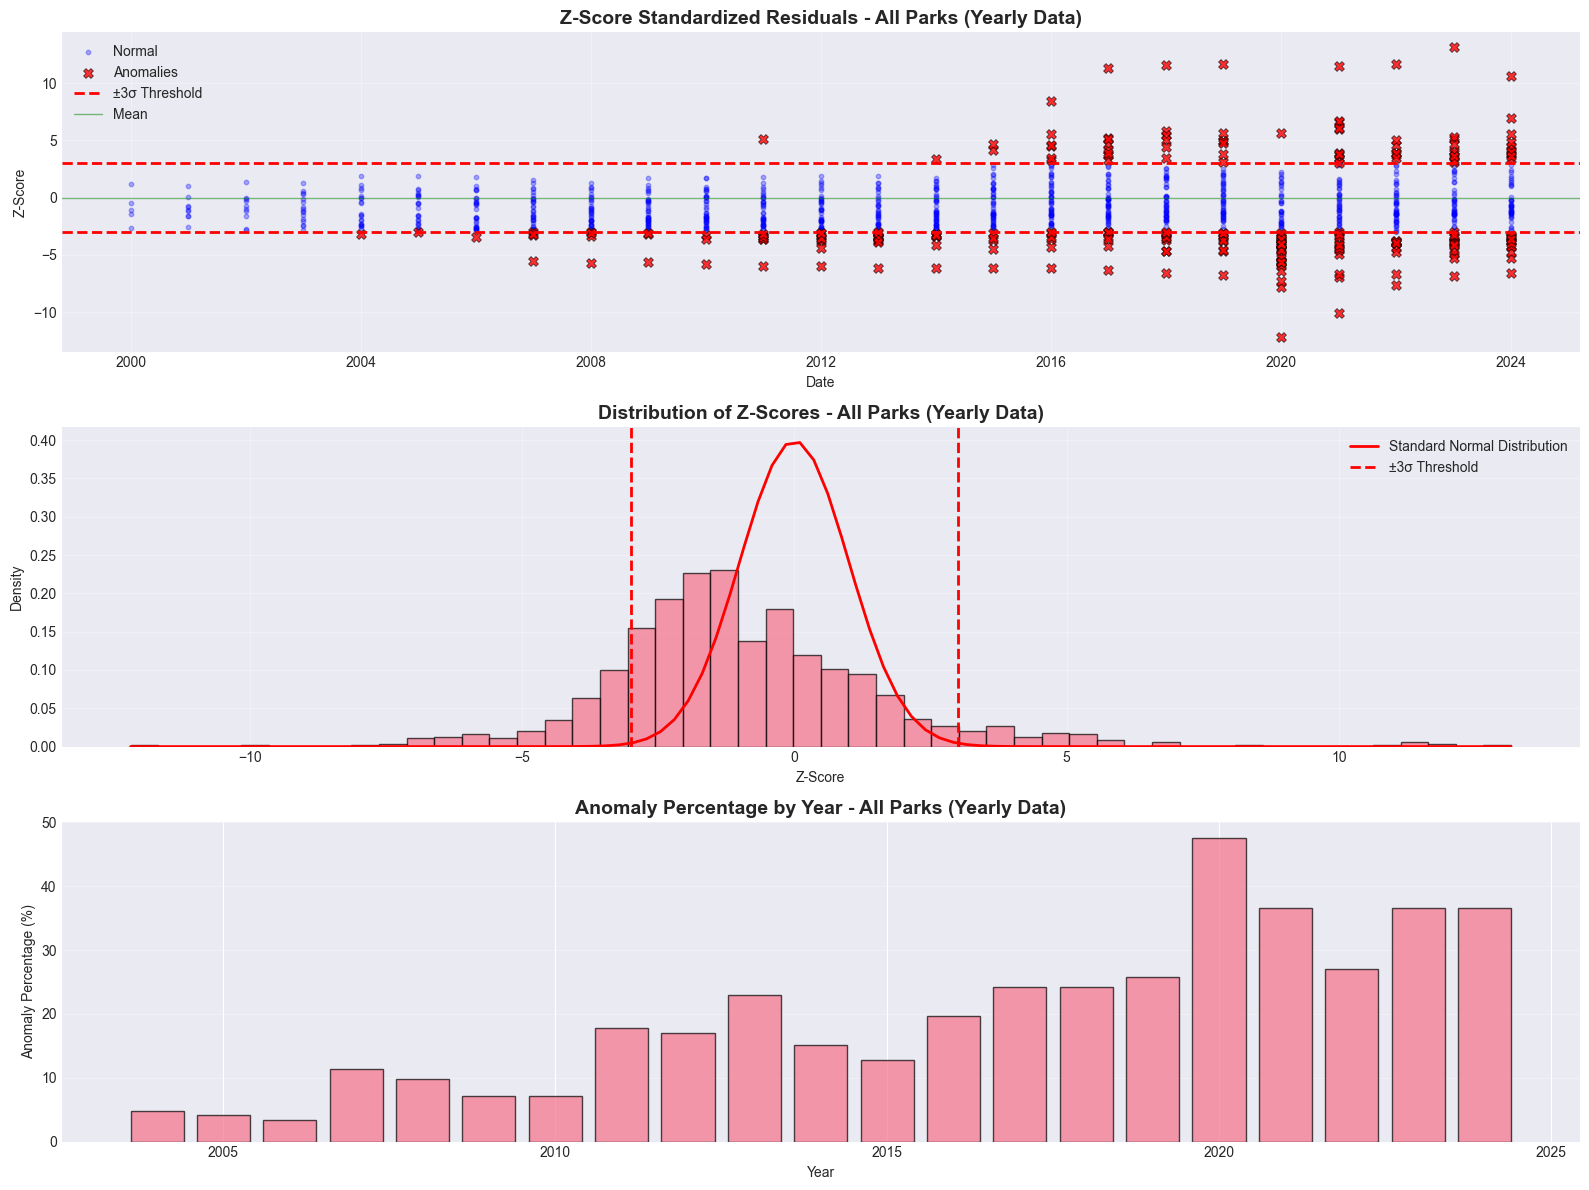

In [88]:
# Visualize combined z-scores over time (yearly)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: All z-scores over time
ax1 = axes[0]
normal_data = residuals_df_yearly[~residuals_df_yearly['Is_Anomaly']]
anomaly_data = residuals_df_yearly[residuals_df_yearly['Is_Anomaly']]

ax1.scatter(normal_data['Date'], normal_data['Z_Score'], alpha=0.3, s=10, label='Normal', color='blue')
ax1.scatter(anomaly_data['Date'], anomaly_data['Z_Score'], alpha=0.8, s=50, 
           marker='X', label='Anomalies', color='red', edgecolors='black', linewidth=0.5)

# Threshold lines
ax1.axhline(y=3, color='red', linestyle='--', linewidth=2, label='±3σ Threshold')
ax1.axhline(y=-3, color='red', linestyle='--', linewidth=2)
ax1.axhline(y=0, color='green', linestyle='-', linewidth=1, alpha=0.5, label='Mean')

ax1.set_title('Z-Score Standardized Residuals - All Parks (Yearly Data)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Z-Score')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of z-scores
ax2 = axes[1]
ax2.hist(residuals_df_yearly['Z_Score'], bins=50, edgecolor='black', alpha=0.7, density=True)

# Overlay normal distribution
x = np.linspace(residuals_df_yearly['Z_Score'].min(), residuals_df_yearly['Z_Score'].max(), 100)
ax2.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label='Standard Normal Distribution')

ax2.axvline(x=3, color='red', linestyle='--', linewidth=2, label='±3σ Threshold')
ax2.axvline(x=-3, color='red', linestyle='--', linewidth=2)

ax2.set_title('Distribution of Z-Scores - All Parks (Yearly Data)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Z-Score')
ax2.set_ylabel('Density')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Plot 3: Anomalies by year
ax3 = axes[2]
yearly_anomalies = residuals_df_yearly[residuals_df_yearly['Is_Anomaly']].groupby('Year').size()
yearly_total = residuals_df_yearly.groupby('Year').size()
yearly_pct = 100 * yearly_anomalies / yearly_total

ax3.bar(yearly_pct.index, yearly_pct.values, edgecolor='black', alpha=0.7)
ax3.set_title('Anomaly Percentage by Year - All Parks (Yearly Data)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Anomaly Percentage (%)')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_anomalies/combined_zscore_yearly.png', dpi=300, bbox_inches='tight')
print("Saved: linear_regression_anomalies/combined_zscore_yearly.png")
plt.show()


### 5.2 Monthly Data - Combined Z-Score Standardized Residuals


In [89]:
# Collect z-score standardized residuals for all parks (monthly)
all_park_residuals_monthly = []
park_list_monthly_all = df_monthly['ParkName'].unique()

for park_name in park_list_monthly_all:
    try:
        park_data = df_monthly[df_monthly["ParkName"] == park_name].copy()
        
        if len(park_data) < 20:
            continue
        
        park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)
        
        X = park_data[['MonthIndex']]
        y = park_data['RecreationVisits']
        
        # Detect anomalies
        results = detect_anomalies_lr(X, y, threshold=3)
        
        # Calculate z-scores for test residuals
        z_scores = (results['residuals_test'] - results['mean_residual']) / results['std_residual']
        
        # Store data
        for idx, (date_idx, z_score, is_anomaly) in enumerate(zip(
            results['X_test'].index, 
            z_scores, 
            results['anomaly_mask']
        )):
            all_park_residuals_monthly.append({
                'Park': park_name,
                'Date': park_data.loc[date_idx, 'Date'],
                'Year': park_data.loc[date_idx, 'Year'],
                'Month': park_data.loc[date_idx, 'Month'],
                'Z_Score': z_score,
                'Is_Anomaly': is_anomaly,
                'Actual': results['y_test'].iloc[idx],
                'Predicted': results['y_test_pred'][idx]
            })
        
    except Exception as e:
        continue

# Create DataFrame
residuals_df_monthly = pd.DataFrame(all_park_residuals_monthly)

print(f"Combined analysis includes {len(park_list_monthly_all)} parks")
print(f"Total data points: {len(residuals_df_monthly)}")
print(f"Total anomalies detected: {residuals_df_monthly['Is_Anomaly'].sum()}")
print(f"Anomaly percentage: {100 * residuals_df_monthly['Is_Anomaly'].sum() / len(residuals_df_monthly):.2f}%")


Combined analysis includes 64 parks
Total data points: 6929
Total anomalies detected: 337
Anomaly percentage: 4.86%


Saved: linear_regression_anomalies/combined_zscore_monthly.png


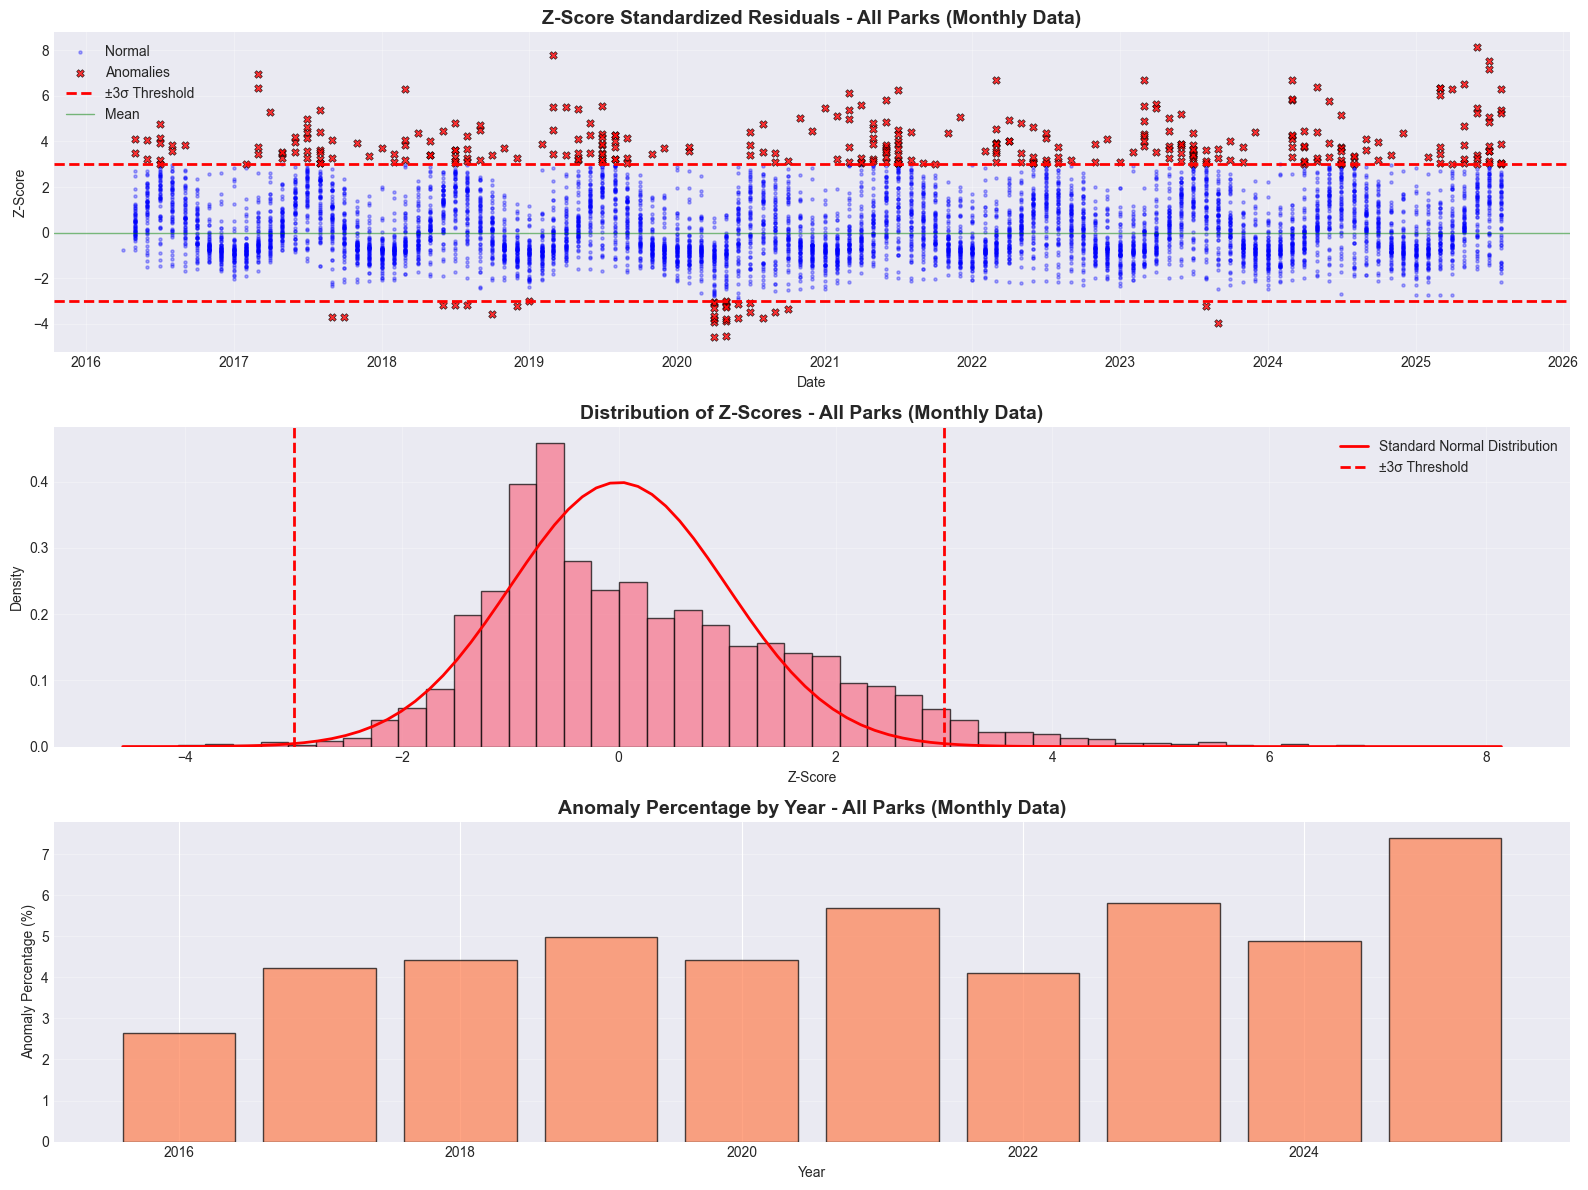

In [90]:
# Visualize combined z-scores over time (monthly)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: All z-scores over time
ax1 = axes[0]
normal_data = residuals_df_monthly[~residuals_df_monthly['Is_Anomaly']]
anomaly_data = residuals_df_monthly[residuals_df_monthly['Is_Anomaly']]

ax1.scatter(normal_data['Date'], normal_data['Z_Score'], alpha=0.3, s=5, label='Normal', color='blue')
ax1.scatter(anomaly_data['Date'], anomaly_data['Z_Score'], alpha=0.8, s=30, 
           marker='X', label='Anomalies', color='red', edgecolors='black', linewidth=0.5)

# Threshold lines
ax1.axhline(y=3, color='red', linestyle='--', linewidth=2, label='±3σ Threshold')
ax1.axhline(y=-3, color='red', linestyle='--', linewidth=2)
ax1.axhline(y=0, color='green', linestyle='-', linewidth=1, alpha=0.5, label='Mean')

ax1.set_title('Z-Score Standardized Residuals - All Parks (Monthly Data)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Z-Score')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of z-scores
ax2 = axes[1]
ax2.hist(residuals_df_monthly['Z_Score'], bins=50, edgecolor='black', alpha=0.7, density=True)

# Overlay normal distribution
x = np.linspace(residuals_df_monthly['Z_Score'].min(), residuals_df_monthly['Z_Score'].max(), 100)
ax2.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label='Standard Normal Distribution')

ax2.axvline(x=3, color='red', linestyle='--', linewidth=2, label='±3σ Threshold')
ax2.axvline(x=-3, color='red', linestyle='--', linewidth=2)

ax2.set_title('Distribution of Z-Scores - All Parks (Monthly Data)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Z-Score')
ax2.set_ylabel('Density')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Plot 3: Anomalies by year
ax3 = axes[2]
yearly_anomalies = residuals_df_monthly[residuals_df_monthly['Is_Anomaly']].groupby('Year').size()
yearly_total = residuals_df_monthly.groupby('Year').size()
yearly_pct = 100 * yearly_anomalies / yearly_total

ax3.bar(yearly_pct.index, yearly_pct.values, edgecolor='black', alpha=0.7, color='coral')
ax3.set_title('Anomaly Percentage by Year - All Parks (Monthly Data)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Anomaly Percentage (%)')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_anomalies/combined_zscore_monthly.png', dpi=300, bbox_inches='tight')
print("Saved: linear_regression_anomalies/combined_zscore_monthly.png")
plt.show()


## 6. Generate and Save Anomaly Plots for All Parks

We'll generate anomaly detection visualizations for each park and save them to a dedicated folder.


In [91]:
import os

# Create directory for saving plots
output_dir = 'linear_regression_anomalies'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# Create subdirectories for yearly and monthly analyses
yearly_dir = os.path.join(output_dir, 'yearly')
monthly_dir = os.path.join(output_dir, 'monthly')

for directory in [yearly_dir, monthly_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created subdirectory: {directory}")
    else:
        print(f"Subdirectory already exists: {directory}")

print("\n" + "="*80)
print("📊 DISPLAY STRATEGY:")
print("="*80)
print("❌ INDIVIDUAL PARK PLOTS: SAVED ONLY (not displayed in notebook)")
print("💾 ALL PARK PLOTS: Saved to yearly/ and monthly/ subdirectories")
print("✅ SUMMARY STATS: Displayed for overview")
print("✅ COMBINED ANALYSIS: Z-score plots displayed (sections 5.1 & 5.2)")
print("="*80)


Directory already exists: linear_regression_anomalies
Created subdirectory: linear_regression_anomalies/yearly
Created subdirectory: linear_regression_anomalies/monthly

📊 DISPLAY STRATEGY:
❌ INDIVIDUAL PARK PLOTS: SAVED ONLY (not displayed in notebook)
💾 ALL PARK PLOTS: Saved to yearly/ and monthly/ subdirectories
✅ SUMMARY STATS: Displayed for overview
✅ COMBINED ANALYSIS: Z-score plots displayed (sections 5.1 & 5.2)


### 6.1 Generate Yearly Anomaly Plots for All Parks (Saved Only)


In [92]:
# Generate and save anomaly detection plots for all parks (yearly data)
print(f"Generating yearly anomaly plots for {len(park_list_yearly)} parks...")
print("="*80)

successful_plots = 0
failed_plots = 0

for park_name in park_list_yearly:
    try:
        # Get park data
        park_data = df_yearly[df_yearly["ParkName"] == park_name].copy()
        
        # Skip if too few data points
        if len(park_data) < 10:
            print(f"⚠️  Skipping {park_name}: insufficient data ({len(park_data)} points)")
            failed_plots += 1
            continue
        
        park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)
        
        X = park_data[['MonthIndex']]
        y = park_data['Total']
        
        # Detect anomalies
        results = detect_anomalies_lr(X, y, threshold=3)
        
        # Generate plot with save_path (no display)
        safe_filename = park_name.replace('/', '-').replace(' ', '_')
        save_path = os.path.join(yearly_dir, f'{safe_filename}_yearly_anomalies.png')
        
        # Create and save plot without displaying
        plot_anomalies(results, park_data['Date'], park_name=f"{park_name} (Yearly)", 
                      save_path=save_path, display=False)
        
        successful_plots += 1
        print(f"✅ Saved: {park_name} - {results['n_anomalies']} anomalies detected")
        
    except Exception as e:
        failed_plots += 1
        print(f"❌ Error processing {park_name}: {str(e)}")
        continue

print("\n" + "="*80)
print(f"Yearly plots complete: {successful_plots} successful, {failed_plots} failed/skipped")
print(f"Plots saved to: {yearly_dir}")


Generating yearly anomaly plots for 63 parks...
Plot saved to linear_regression_anomalies/yearly/Acadia_NP_yearly_anomalies.png
✅ Saved: Acadia NP - 2 anomalies detected
Plot saved to linear_regression_anomalies/yearly/Arches_NP_yearly_anomalies.png
✅ Saved: Arches NP - 10 anomalies detected
Plot saved to linear_regression_anomalies/yearly/Badlands_NP_yearly_anomalies.png
✅ Saved: Badlands NP - 0 anomalies detected
Plot saved to linear_regression_anomalies/yearly/Big_Bend_NP_yearly_anomalies.png
✅ Saved: Big Bend NP - 4 anomalies detected
Plot saved to linear_regression_anomalies/yearly/Biscayne_NP_yearly_anomalies.png
✅ Saved: Biscayne NP - 0 anomalies detected
Plot saved to linear_regression_anomalies/yearly/Black_Canyon_of_the_Gunnison_NP_yearly_anomalies.png
✅ Saved: Black Canyon of the Gunnison NP - 0 anomalies detected
Plot saved to linear_regression_anomalies/yearly/Bryce_Canyon_NP_yearly_anomalies.png
✅ Saved: Bryce Canyon NP - 7 anomalies detected
Plot saved to linear_regressi

### 6.2 Generate Monthly Anomaly Plots for All Parks (Saved Only)


In [93]:
# Get list of all parks from monthly data
park_list_monthly = df_monthly['ParkName'].unique()

# Generate and save anomaly detection plots for all parks (monthly data)
print(f"Generating monthly anomaly plots for {len(park_list_monthly)} parks...")
print("="*80)

successful_plots_monthly = 0
failed_plots_monthly = 0

for park_name in park_list_monthly:
    try:
        # Get park data
        park_data = df_monthly[df_monthly["ParkName"] == park_name].copy()
        
        # Skip if too few data points
        if len(park_data) < 20:
            print(f"⚠️  Skipping {park_name}: insufficient data ({len(park_data)} points)")
            failed_plots_monthly += 1
            continue
        
        park_data['MonthIndex'] = park_data['Date'].map(pd.Timestamp.toordinal)
        
        X = park_data[['MonthIndex']]
        y = park_data['RecreationVisits']
        
        # Detect anomalies
        results = detect_anomalies_lr(X, y, threshold=3)
        
        # Generate plot with save_path (no display)
        safe_filename = park_name.replace('/', '-').replace(' ', '_')
        save_path = os.path.join(monthly_dir, f'{safe_filename}_monthly_anomalies.png')
        
        # Create and save plot without displaying
        plot_anomalies(results, park_data['Date'], park_name=f"{park_name} (Monthly)", 
                      save_path=save_path, display=False)
        
        successful_plots_monthly += 1
        print(f"✅ Saved: {park_name} - {results['n_anomalies']} anomalies detected")
        
    except Exception as e:
        failed_plots_monthly += 1
        print(f"❌ Error processing {park_name}: {str(e)}")
        continue

print("\n" + "="*80)
print(f"Monthly plots complete: {successful_plots_monthly} successful, {failed_plots_monthly} failed/skipped")
print(f"Plots saved to: {monthly_dir}")


Generating monthly anomaly plots for 64 parks...
Plot saved to linear_regression_anomalies/monthly/Acadia_NP_monthly_anomalies.png
✅ Saved: Acadia NP - 1 anomalies detected
Plot saved to linear_regression_anomalies/monthly/Arches_NP_monthly_anomalies.png
✅ Saved: Arches NP - 1 anomalies detected
Plot saved to linear_regression_anomalies/monthly/Badlands_NP_monthly_anomalies.png
✅ Saved: Badlands NP - 0 anomalies detected
Plot saved to linear_regression_anomalies/monthly/Big_Bend_NP_monthly_anomalies.png
✅ Saved: Big Bend NP - 12 anomalies detected
Plot saved to linear_regression_anomalies/monthly/Biscayne_NP_monthly_anomalies.png
✅ Saved: Biscayne NP - 0 anomalies detected
Plot saved to linear_regression_anomalies/monthly/Black_Canyon_of_the_Gunnison_NP_monthly_anomalies.png
✅ Saved: Black Canyon of the Gunnison NP - 3 anomalies detected
Plot saved to linear_regression_anomalies/monthly/Bryce_Canyon_NP_monthly_anomalies.png
✅ Saved: Bryce Canyon NP - 29 anomalies detected
Plot saved to